In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [11]:
ishigami_problem ={
    'num_vars': 3,
    'names': ['x1', 'x2', 'x3'],
    'bounds': [[-3.14159265359, 3.14159265359],
               [-3.14159265359, 3.14159265359],
               [-3.14159265359, 3.14159265359]]
}
X_morris = morris_samp.sample(ishigami_problem, 1000, num_levels=4)
X_morris.shape

(4000, 3)

In [ ]:
ssn = 1001 # Number of time datapoints

qx = [-1.800,0,1.800,-1.800,0,1.800] # Qubit x-locations
qy = [-1.900,-1.870,-1.900,1.870,1.890,1.870] #Qubit y-locations
phNos = np.zeros((len(qx),ssn)) # Number of phonons which hit each qubit at a given time division
QPNos = np.zeros((len(qx),ssn)) # Number of quasiparticles generated on each qubit at a given time division
rec = pd.read_csv('/Users/paulbaity/Geant4/G4CMP/BNL_G4CMP/Main/Sensitivity/output_setTopFilmAbs_0.859.txt')
# rec = rec.sort_values(['Event ID', 'Track ID', 'Final Time [ns]'], ascending = [True, True, True])
    
snapshot_t = np.linspace(0, 100000, ssn) # Time vector in ns
#Check where phonons are depositing energy on the surface of the chip; phonons emitted from junctions also recorded in file
hits = np.where((rec['Energy Deposited [eV]'] > 0) & (rec['End Z [m]'] == 0.000175))[0]

#For each hit, determine which qubit the phonon struck and at what time division; build the statistics for phNos and QPNos
#2*179.75e-6 is the energy required to make 1 quasiparticle. Energy Deposited will always be an integer multiple of this value.
for h in hits:
    for q in range(len(qx)):
        if np.round(1000*rec['End X [m]'][h],1) == qx[q] and np.round(1000*rec['End Y [m]'][h],2) == qy[q]:
            phNos[q,np.argmin(np.abs(rec['Final Time [ns]'][h] - snapshot_t))] += 1
            QPNos[q,np.argmin(np.abs(rec['Final Time [ns]'][h] - snapshot_t))] += int(np.round(rec['Energy Deposited [eV]'][h]/(2*179.75e-6)))

In [ ]:
#Plot the number of QPs generated on each qubit as a function of time
for i in range(len(qx)):
    plt.plot(0.001*snapshot_t,QPNos[i,:],'-')
    
plt.ylabel('Quasiparticles Generated')
plt.xlabel('Simulation Time (us)')

In [ ]:
pt = 10 #pulse time in us
dt = np.mean(np.diff(snapshot_t))*0.001 #time resolution
t = np.linspace(0.001*snapshot_t[0], 0.001*snapshot_t[-1] + pt, len(snapshot_t) + int(np.round(pt/dt)))
g_QP = np.zeros((QPNos.shape[0],len(t)))
n_QP = np.zeros((QPNos.shape[0],len(t)))

for k in range(QPNos.shape[0]):
    for i in range(int(np.round(pt/dt))):
        g_QP[k,i:len(QPNos[k,:])+i] = g_QP[k,i:len(QPNos[k,:])+i] + QPNos[k,:]/(10*10*0.1*dt)
    
    g_QP[k,:] = g_QP[k,:]/(pt/dt)
    for i in range(len(g_QP[k,:])):
        if t[i] < pt:
            g_QP[k,i] = g_QP[k,i]*t[i]*1.673*8.916e5/1000e6
        else:
            g_QP[k,i] = g_QP[k,i]*pt*1.673*8.916e5/1000e6
    
    for i in range(len(g_QP[k,:])-1):
        dn = (-25e-6*n_QP[k,i]**2 - 0.07*n_QP[k,i] + g_QP[k,i])*dt
        n_QP[k,i+1] = n_QP[k,i] + dn
    
    plt.plot(t-pt,n_QP[k,:]/4e6,'o', label = 'Qubit ' + str(k+1))

plt.xlabel('Time ($\mu$s)')
plt.ylabel('$x_{qp}$')
plt.legend(loc = 'upper right')
# plt.yscale('log')
# plt.xlim(0,100)
# plt.ylim(1e-6,5e-4)

x1 = t-pt
y1 = n_QP[2,:]/4e6
# x1 = 

In [ ]:
plt.plot(x0,y0)
plt.plot(x1,y1,'-')
plt.plot(x2,y2)

plt.fill_between(
    x0,
    y0,
    y1,
    alpha=0.5,
    label=r"95% confidence interval",
)

In [ ]:
def setTopAbs(value):
    input_file = '/Users/paulbaity/Geant4/G4CMP/BNL_G4CMP/Main/Sensitivity/sensitivity_template.mac'
    output_file = '/Users/paulbaity/Geant4/G4CMP/BNL_G4CMP/Main/Sensitivity/sensitivity_setTopAbs_' + str(value) + '.mac'
    with open(input_file, 'r') as file:
        lines = file.readlines()

    # Replace the specified lines with data from x, y, and r
    for i, line in enumerate(lines):
        if line.startswith("/main/detector_param/setTopAbs"):
            lines[i] = "/main/detector_param/setTopAbs " + str(value) + '\n'
        elif line.startswith("/g4cmp/HitsFile"):
            lines[i] = "/g4cmp/HitsFile Sensitivity/output_setTopAbs_" + str(value) + '.txt\n'

    with open(output_file, 'w') as file:
        file.writelines(lines)

    return output_file

PATH_TO_GEANT4_ENV = "/Users/paulbaity/Geant4/Geant4-Install/share/Geant4-10.7.4/geant4make/geant4make.sh"
PATH_TO_G4CMP_ENV = "/Users/paulbaity/Geant4/G4CMP/g4cmp_env.sh"
# values = np.round([0.795, 0.996],3)
values = np.round([0.963],3)
for i in values:
    runfile = setTopAbs(i)
    os.system(  "source " + PATH_TO_GEANT4_ENV + "; "
              + "source " + PATH_TO_G4CMP_ENV + "; "
              + "cd " + "/Users/paulbaity/Geant4/G4CMP/BNL_G4CMP/Main/" + "; "
              + "Main " + runfile + ";")

In [ ]:
def setTopFilmAbs(value):
    input_file = '/Users/paulbaity/Geant4/G4CMP/BNL_G4CMP/Main/Sensitivity/sensitivity_template.mac'
    output_file = '/Users/paulbaity/Geant4/G4CMP/BNL_G4CMP/Main/Sensitivity/sensitivity_setTopFilmAbs_' + str(value) + '.mac'
    with open(input_file, 'r') as file:
        lines = file.readlines()

    # Replace the specified lines with data from x, y, and r
    for i, line in enumerate(lines):
        if line.startswith("/main/detector_param/setTopFilmAbs"):
            lines[i] = "/main/detector_param/setTopFilmAbs " + str(value) + '\n'
        elif line.startswith("/g4cmp/HitsFile"):
            lines[i] = "/g4cmp/HitsFile Sensitivity/output_setTopFilmAbs_" + str(value) + '.txt\n'

    with open(output_file, 'w') as file:
        file.writelines(lines)

    return output_file

PATH_TO_GEANT4_ENV = "/Users/paulbaity/Geant4/Geant4-Install/share/Geant4-10.7.4/geant4make/geant4make.sh"
PATH_TO_G4CMP_ENV = "/Users/paulbaity/Geant4/G4CMP/g4cmp_env.sh"
# values = np.round([0.745, 0.8587],3)
values = np.round([0.093*0.7306935536693709 + (1-0.093)*0.8249791515011013],3)
for i in values:
    runfile = setTopFilmAbs(i)
    os.system(  "source " + PATH_TO_GEANT4_ENV + "; "
              + "source " + PATH_TO_G4CMP_ENV + "; "
              + "cd " + "/Users/paulbaity/Geant4/G4CMP/BNL_G4CMP/Main/" + "; "
              + "Main " + runfile + ";")

In [ ]:
def setBotAbs(value):
    input_file = '/Users/paulbaity/Geant4/G4CMP/BNL_G4CMP/Main/Sensitivity/sensitivity_template.mac'
    output_file = '/Users/paulbaity/Geant4/G4CMP/BNL_G4CMP/Main/Sensitivity/sensitivity_setBotAbs_' + str(value) + '.mac'
    with open(input_file, 'r') as file:
        lines = file.readlines()

    # Replace the specified lines with data from x, y, and r
    for i, line in enumerate(lines):
        if line.startswith("/main/detector_param/setBotAbs"):
            lines[i] = "/main/detector_param/setBotAbs " + str(value) + '\n'
        elif line.startswith("/g4cmp/HitsFile"):
            lines[i] = "/g4cmp/HitsFile Sensitivity/output_setBotAbs_" + str(value) + '.txt\n'

    with open(output_file, 'w') as file:
        file.writelines(lines)

    return output_file

PATH_TO_GEANT4_ENV = "/Users/paulbaity/Geant4/Geant4-Install/share/Geant4-10.7.4/geant4make/geant4make.sh"
PATH_TO_G4CMP_ENV = "/Users/paulbaity/Geant4/G4CMP/g4cmp_env.sh"
# values = np.round([0.792, 0.9739],3)
values = np.round([0.093*0.8906002108204152 + (1-0.093)*0.9111794944059395],3)
for i in values:
    runfile = setBotAbs(i)
    os.system(  "source " + PATH_TO_GEANT4_ENV + "; "
              + "source " + PATH_TO_G4CMP_ENV + "; "
              + "cd " + "/Users/paulbaity/Geant4/G4CMP/BNL_G4CMP/Main/" + "; "
              + "Main " + runfile + ";")

In [ ]:
# The probability of a prepared 1 state decaying into a 0 state is P = 1 - e^(-\Gamma*t)
# \Gamma can be calculated as the integrated decay rate up to time t
for k in range(QPNos.shape[0]):
    P1_muon = []
    P1_norm = []
    for i in range(len(t)):
        P1_muon.append(1-np.exp(-np.sum((Factor*n_QP[k,:i]/4e6 + 1/T1b)*dt)))
        P1_norm.append(1-np.exp(-np.sum((0*n_QP[k,:i]/4e6 + 1/T1b)*dt)))

    plt.plot(t,P1_muon, label = 'Muon Hit, Qubit ' + str(k + 1))

plt.plot(t,P1_norm, label = 'Normal Decay')
plt.legend(loc = 'lower right')
plt.xlabel('time ($\mu$s)')
plt.ylabel('Probability of $|1>$ Decay')
plt.text(20,0,'1 um of Ti on back of chip')
plt.axvline(pt,color = 'k', linestyle = '--')
plt.text(pt-3,0.4,'Muon Strike', rotation = 90)

11581


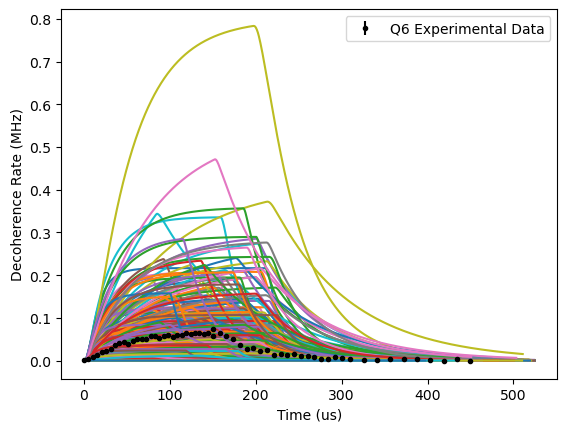

In [2]:
def calculate_QPs(rec,gap):
    ssn = 1001 # Number of time datapoints
    qx = [-1.64,-2.4405,0.4,-0.4,2.42,1.62] # Qubit x-locations
    qy = [2.2795,-2.2735,2.2735,-2.2795,2.2795,-2.2735] #Qubit y-locations
    phNos = np.zeros((len(qx),ssn)) # Number of phonons which hit each qubit at a given time division
    QPNos = np.zeros((len(qx),ssn)) # Number of quasiparticles generated on each qubit at a given time division
    snapshot_t = np.linspace(0, 300000, ssn) # Time vector in ns
    hits = np.where((rec['Energy Deposited [eV]'] > 0) & (rec['End Z [m]'] == 0.0002625))[0]

    #For each hit, determine which qubit the phonon struck and at what time division; build the statistics for phNos and QPNos
    #2*179.75e-6 is the energy required to make 1 quasiparticle. Energy Deposited will always be an integer multiple of this value.
    for h in hits:
        r = ((1000*rec['End X [m]'][h] - qx)**2 + (1000*rec['End Y [m]'][h] - qy)**2)**0.5
        q = np.argmin(r)
        # for q in range(len(qx)):
        #     if np.round(1000*rec['End X [m]'][h],2) == np.round(qx[q],2) and np.round(1000*rec['End Y [m]'][h],2) == np.round(qy[q],2):
                # print("truth condition met")
        phNos[q,np.argmin(np.abs(rec['Final Time [ns]'][h] - snapshot_t))] += 1
        QPNos[q,np.argmin(np.abs(rec['Final Time [ns]'][h] - snapshot_t))] += int(np.round(rec['Energy Deposited [eV]'][h]/(gap)))

    return snapshot_t, QPNos

def calculate_xQPs(snapshot_t,QPNos,AlGap,f_01,r,s,I_ph,pt,n_cooper,height,width,thickness):
    # pt = 10 #pulse time in us
    dt = np.mean(np.diff(snapshot_t))*0.001 #time resolution
    t = np.linspace(0.001*snapshot_t[0], 0.001*snapshot_t[-1] + pt, len(snapshot_t) + int(np.round(pt/dt)))
    g_QP = np.zeros((QPNos.shape[0],len(t)))
    x_QP = np.zeros((QPNos.shape[0],len(t)))
    Factor = 2*np.sqrt(2*AlGap*f_01[:])*1e-6
    DG = np.zeros((QPNos.shape[0],len(t)))
    N_sim = 1e8

    for k in range(QPNos.shape[0]):
        for i in range(int(np.round(pt/dt))):
            g_QP[k,i:len(QPNos[k,:])+i] = g_QP[k,i:len(QPNos[k,:])+i] + QPNos[k,:]*I_ph/(n_cooper*height*width*thickness*N_sim)
    
        for i in range(len(g_QP[k,:])-1):
            dx = (-r*x_QP[k,i]**2 - s[k]*x_QP[k,i] + g_QP[k,i])*dt
            x_QP[k,i+1] = x_QP[k,i] + dx

        DG[k,:] = x_QP[k,:]*Factor[k]
    
    return t, DG

sequence = pd.read_csv('/Users/paulbaity/Geant4/BNL_G4CMP/Main/Sensitivity/1673d18b-129c-4957-bc60-b585bee03145_hits/SobolSequence.csv')
output_x = []
output_y0 = []
output_y1 = []
output_y2 = []
output_y3 = []
output_y4 = []
output_y5 = []
good = 0
for i in range(0,2**14):
    try:
    # if 1 == 1:
        rec = pd.read_csv('/Users/paulbaity/Geant4/BNL_G4CMP/Main/Sensitivity/1673d18b-129c-4957-bc60-b585bee03145_hits/Sobol_' + str(i) + '_hitsfile.txt')
        if len(rec) > 0:
            gap = sequence["/main/detector_param/setTopGap "][i]
            times, QPs = calculate_QPs(rec,gap)
            height = sequence["/main/electrode_param/setHeight "][i]
            width = sequence["/main/electrode_param/setWidth "][i]
            thickness = sequence["/main/detector_param/setTopThickness "][i]
            n_cooper = sequence["n_cooper"][i]
            pt = sequence["pt"][i]
            I_ph = sequence["I_ph"][i]
            s = np.array([sequence["s_1"][i],sequence["s_2"][i],sequence["s_3"][i],sequence["s_4"][i],sequence["s_5"][i],sequence["s_6"][i]])
            r = sequence["r"][i]
            f_01 = np.array([sequence["f_01_1"][i],sequence["f_01_2"][i],sequence["f_01_3"][i],sequence["f_01_4"][i],sequence["f_01_5"][i],sequence["f_01_6"][i]])
            # AlGap = sequence["AlGap"][i]
            AlGap = sequence["/main/detector_param/setTopGap "][i]/(4.135667696e-15)
            nt, DG = calculate_xQPs(times,QPs,AlGap,f_01,r,s,I_ph,pt,n_cooper,height,width,thickness)

            plt.plot(nt,DG[0,:])
            output_x.append(nt)
            output_y0.append(DG[0,:])
            output_y1.append(DG[1,:])
            output_y2.append(DG[2,:])
            output_y3.append(DG[3,:])
            output_y4.append(DG[4,:])
            output_y5.append(DG[5,:])
            good += 1

        else:
            output_x.append([])
            output_y0.append([])
            output_y1.append([])
            output_y2.append([])
            output_y3.append([])
            output_y4.append([])
            output_y5.append([])

    except:
        output_x.append([])
        output_y0.append([])
        output_y1.append([])
        output_y2.append([])
        output_y3.append([])
        output_y4.append([])
        output_y5.append([])

plt.ylabel('Decoherence Rate (MHz)')
plt.xlabel('Time (us)')
print(good)

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_1umCu_B2_Q0Inj_150us_staggered/Qubit_0_NbGND_1umCu_VI09_B2_DeltaGamma_v_Delay_Q0inj_150us_DuringPulse.txt',delimiter =' ',skiprows=0)
x = delay_data[0]
y = delay_data[1]
dy = delay_data[2]

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_1umCu_B2_Q0Inj_150us_staggered/Qubit_0_NbGND_1umCu_VI09_B2_DeltaGamma_v_Delay_Q0inj_150us.txt',delimiter =' ',skiprows=0)
x0_data = np.append(x,delay_data[0]) - np.min(x)
y0_data = np.append(y,delay_data[1])
dy0_data = np.append(dy,delay_data[2])
plt.errorbar(x0_data,y0_data,yerr=dy0_data, fmt = '.', color = 'k', label = 'Q6 Experimental Data')
plt.legend(loc = 'upper right')

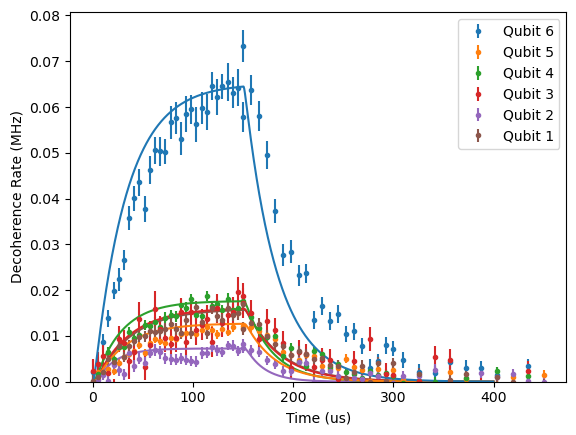

In [3]:
def calculate_QPs(rec,gap):
    ssn = 1001 # Number of time datapoints
    qx = np.array([-1.64,-2.4405,0.4,-0.4,2.42,1.62]) # Qubit x-locations
    qy = np.array([2.2795,-2.2735,2.2735,-2.2795,2.2795,-2.2735]) #Qubit y-locations
    phNos = np.zeros((len(qx),ssn)) # Number of phonons which hit each qubit at a given time division
    QPNos = np.zeros((len(qx),ssn)) # Number of quasiparticles generated on each qubit at a given time division
    snapshot_t = np.linspace(0, 300000, ssn) # Time vector in ns
    hits = np.where((rec['Energy Deposited [eV]'] > 0) & (rec['End Z [m]'] == 0.0002625))[0]

    #For each hit, determine which qubit the phonon struck and at what time division; build the statistics for phNos and QPNos
    #2*179.75e-6 is the energy required to make 1 quasiparticle. Energy Deposited will always be an integer multiple of this value.
    for h in hits:
        r = ((1000*rec['End X [m]'][h] - qx)**2 + (1000*rec['End Y [m]'][h] - qy)**2)**0.5
        q = np.argmin(r)
        # for q in range(len(qx)):
        #     if np.round(1000*rec['End X [m]'][h],2) == np.round(qx[q],2) and np.round(1000*rec['End Y [m]'][h],2) == np.round(qy[q],2):
                # print("truth condition met")
        phNos[q,np.argmin(np.abs(rec['Final Time [ns]'][h] - snapshot_t))] += 1
        QPNos[q,np.argmin(np.abs(rec['Final Time [ns]'][h] - snapshot_t))] += int(np.round(rec['Energy Deposited [eV]'][h]/(gap)))

    return snapshot_t, QPNos
    
def calculate_xQPs(snapshot_t,QPNos,AlGap,f_01,r,s,I_ph,pt,n_cooper,height,width,thickness):
    # pt = 10 #pulse time in us
    dt = np.mean(np.diff(snapshot_t))*0.001 #time resolution
    t = np.linspace(0.001*snapshot_t[0], 0.001*snapshot_t[-1] + pt, len(snapshot_t) + int(np.round(pt/dt)))
    g_QP = np.zeros((QPNos.shape[0],len(t)))
    x_QP = np.zeros((QPNos.shape[0],len(t)))
    Factor = 2*np.sqrt(2*AlGap*f_01[:])*1e-6
    DG = np.zeros((QPNos.shape[0],len(t)))
    N_sim = 1000000000

    signal = np.zeros(len(t))
    for i in range(len(t)):
        if t[i] <= pt:
            signal[i]=I_ph

    for k in range(QPNos.shape[0]):
        # for i in range(int(np.round(pt/dt))):
        #     g_QP[k,i:len(QPNos[k,:])+i] += QPNos[k,:]*I_ph/(n_cooper*height*width*thickness*N_sim)
            # g_QP[k,i:len(QPNos[k,:])+i] += QPNos[k,:]*I_ph/(0.6*20*N_sim*n_cooper)
        #     # g_QP[k,i] += np.sum(QPNos[k,:i])*I_ph/(0.6*20*N_sim)

        # Optional numpy.convolution method
        g_QP[k,:] = np.convolve(QPNos[k,:],signal,mode='full')[:len(t)]/(n_cooper*height*width*thickness*N_sim)
        
        for i in range(len(g_QP[k,:])-1):
            dx = (-r*x_QP[k,i]**2 - s[k]*x_QP[k,i] + g_QP[k,i])*dt
            x_QP[k,i+1] = x_QP[k,i] + dx

        DG[k,:] = x_QP[k,:]*Factor[k]
    
    # return snapshot_t, QPNos
    return t, DG
    
rec = pd.read_csv('/Users/paulbaity/Geant4/BNL_G4CMP/Main/Sensitivity/output_test_wall0.025.txt')
# rec = pd.read_csv('/Users/paulbaity/Geant4/BNL_G4CMP/Main/macros/phonon_hits_Cu1umInj_0p025WallAbs_Q0Inj_1B_10x10_45Deg_TrueJJ_newFilmAbs_200umIslands.txt')
times, QPs = calculate_QPs(rec,191.0e-6)

height = 10
width = 10
thickness = 0.12
n_cooper = 4.0e6
pt = 150
I_ph = 1.67259*6.7578e5
s = np.array([0.02808,0.0523,0.0292,0.0371,0.0331,0.03038])
r = 25e-6
f_01 = np.array([4.62e9,4.30e9,4.32e9,4.36e9,4.34e9,4.32e9])
AlGap = 191.0e-6/(4.135667696e-15)
Factor = 2*np.sqrt(2*173.0e-6/(4.135667696e-15)*f_01[:])*1e-6
nt, DG = calculate_xQPs(times,QPs,AlGap,f_01,r,s,I_ph,pt,n_cooper,height,width,thickness)

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_1umCu_B2_Q0Inj_150us_staggered/Qubit_0_NbGND_1umCu_VI09_B2_DeltaGamma_v_Delay_Q0inj_150us_DuringPulse.txt',delimiter =' ',skiprows=0)
x = delay_data[0]
y = delay_data[1]
dy = delay_data[2]

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_1umCu_B2_Q0Inj_150us_staggered/Qubit_0_NbGND_1umCu_VI09_B2_DeltaGamma_v_Delay_Q0inj_150us.txt',delimiter =' ',skiprows=0)
x0_data = np.append(x,delay_data[0]) - np.min(x)
y0_data = np.append(y,delay_data[1])
dy0_data = np.append(dy,delay_data[2])
plt.figure()
plt.errorbar(x0_data,y0_data,yerr=dy0_data, fmt = '.', color = 'C0', label = 'Qubit 6')

# plt.plot(nt,DG[5,:], color = 'C0')
# plt.fill_between(nt,DG[5,:], alpha = 0.3, color = 'C0')
plt.ylim(0,)
plt.ylabel('Decoherence Rate (MHz)')
plt.xlabel('Time (us)')

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_1umCu_B2_Q0Inj_150us_staggered/Qubit_1_NbGND_1umCu_VI09_B2_DeltaGamma_v_Delay_Q0inj_150us_DuringPulse.txt',delimiter =' ',skiprows=0)
x = delay_data[0]
y = delay_data[1]
dy = delay_data[2]

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_1umCu_B2_Q0Inj_150us_staggered/Qubit_1_NbGND_1umCu_VI09_B2_DeltaGamma_v_Delay_Q0inj_150us.txt',delimiter =' ',skiprows=0)
x1_data = np.append(x,delay_data[0]) - np.min(x)
y1_data = np.append(y,delay_data[1])
dy1_data = np.append(dy,delay_data[2])
# plt.figure()
plt.errorbar(x1_data,y1_data,yerr=dy1_data, fmt = '.', color = 'C1', label = 'Qubit 5')

# plt.plot(nt,DG[4,:],color = 'C1')
# plt.fill_between(nt,DG[4,:], alpha = 0.3, color = 'C1')
plt.ylim(0,)
plt.ylabel('Decoherence Rate (MHz)')
plt.xlabel('Time (us)')

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_1umCu_B2_Q0Inj_150us_staggered/Qubit_2_NbGND_1umCu_VI09_B2_DeltaGamma_v_Delay_Q0inj_150us_DuringPulse.txt',delimiter =' ',skiprows=0)
x = delay_data[0]
y = delay_data[1]
dy = delay_data[2]

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_1umCu_B2_Q0Inj_150us_staggered/Qubit_2_NbGND_1umCu_VI09_B2_DeltaGamma_v_Delay_Q0inj_150us.txt',delimiter =' ',skiprows=0)
x2_data = np.append(x,delay_data[0]) - np.min(x)
y2_data = np.append(y,delay_data[1])
dy2_data = np.append(dy,delay_data[2])
# plt.figure()
plt.errorbar(x2_data,y2_data,yerr=dy2_data, fmt = '.', color = 'C2', label = 'Qubit 4')

# plt.plot(nt,DG[3,:],color = 'C2')
# plt.fill_between(nt,DG[3,:], alpha = 0.3, color = 'C2')
plt.ylim(0,)
plt.ylabel('Decoherence Rate (MHz)')
plt.xlabel('Time (us)')

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_1umCu_B2_Q0Inj_150us_staggered/Qubit_3_NbGND_1umCu_VI09_B2_DeltaGamma_v_Delay_Q0inj_150us_DuringPulse.txt',delimiter =' ',skiprows=0)
x = delay_data[0]
y = delay_data[1]
dy = delay_data[2]

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_1umCu_B2_Q0Inj_150us_staggered/Qubit_3_NbGND_1umCu_VI09_B2_DeltaGamma_v_Delay_Q0inj_150us.txt',delimiter =' ',skiprows=0)
x3_data = np.append(x,delay_data[0]) - np.min(x)
y3_data = np.append(y,delay_data[1])
dy3_data = np.append(dy,delay_data[2])
# plt.figure()
plt.errorbar(x3_data,y3_data,yerr=dy3_data, fmt = '.', color = 'C3', label = 'Qubit 3')

# plt.plot(nt,DG[2,:],color = 'C3')
# plt.fill_between(nt,DG[2,:], alpha = 0.3, color = 'C3')
plt.ylim(0,)
plt.ylabel('Decoherence Rate (MHz)')
plt.xlabel('Time (us)')

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_1umCu_B2_Q0Inj_150us_staggered/Qubit_4_NbGND_1umCu_VI09_B2_DeltaGamma_v_Delay_Q0inj_150us_DuringPulse.txt',delimiter =' ',skiprows=0)
x = delay_data[0]
y = delay_data[1]
dy = delay_data[2]

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_1umCu_B2_Q0Inj_150us_staggered/Qubit_4_NbGND_1umCu_VI09_B2_DeltaGamma_v_Delay_Q0inj_150us.txt',delimiter =' ',skiprows=0)
x4_data = np.append(x,delay_data[0]) - np.min(x)
y4_data = np.append(y,delay_data[1])
dy4_data = np.append(dy,delay_data[2])
# plt.figure()
plt.errorbar(x4_data,y4_data,yerr=dy4_data, fmt = '.', color = 'C4', label = 'Qubit 2')

# plt.plot(nt,DG[1,:],color = 'C4')
# plt.fill_between(nt,DG[1,:], alpha = 0.3, color = 'C4')
plt.ylim(0,)
plt.ylabel('Decoherence Rate (MHz)')
plt.xlabel('Time (us)')

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_1umCu_B2_Q0Inj_150us_staggered/Qubit_5_NbGND_1umCu_VI09_B2_DeltaGamma_v_Delay_Q0inj_150us_DuringPulse.txt',delimiter =' ',skiprows=0)
x = delay_data[0]
y = delay_data[1]
dy = delay_data[2]

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_1umCu_B2_Q0Inj_150us_staggered/Qubit_5_NbGND_1umCu_VI09_B2_DeltaGamma_v_Delay_Q0inj_150us.txt',delimiter =' ',skiprows=0)
x5_data = np.append(x,delay_data[0]) - np.min(x)
y5_data = np.append(y,delay_data[1])
dy5_data = np.append(dy,delay_data[2])
# plt.figure()
plt.errorbar(x5_data,y5_data,yerr=dy5_data, fmt = '.', color = 'C5', label = 'Qubit 1')

# plt.plot(nt,DG[0,:],color = 'C5')
# plt.fill_between(nt,DG[0,:], alpha = 0.3, color = 'C5')
plt.ylim(0,)
plt.legend(loc = 'upper right')
plt.ylabel('Decoherence Rate (MHz)')
plt.xlabel('Time (us)')

time_sol = np.array([])
n_qp_sol = np.array([])
for q in range(0,6):
    t = np.loadtxt("/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/Cu_1um_Injection_time_sol_"+str(q))
    n = np.loadtxt("/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/Cu_1um_Injection_n_qp_sol_"+str(q))
    time_sol = np.append(time_sol,t)
    n_qp_sol = np.append(n_qp_sol,n)
    plt.plot(t,Factor[q]*n/4.4e6,'C'+str(5-q)+'-')
    # plt.plot(nt[:],DG[q,:],'C'+str(5-q)+'--')


Text(0.5, 0, 'Time (us)')

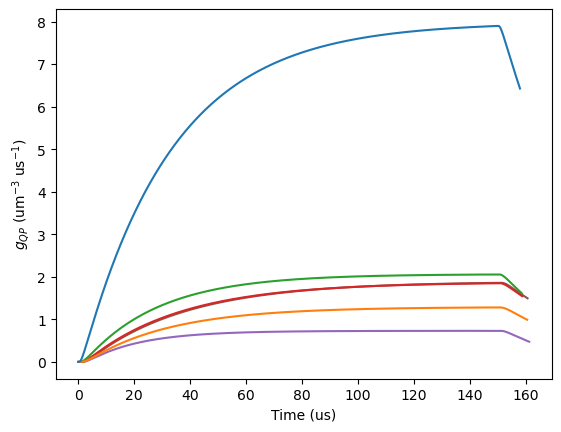

In [18]:
time_sol = np.array([])
n_qp_sol = np.array([])
for q in range(0,6):
    t = np.loadtxt("/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/Cu_1um_Injection_time_sol_"+str(q))
    n = np.loadtxt("/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/Cu_1um_Injection_n_qp_sol_"+str(q))
    time_sol = np.append(time_sol,t)
    n_qp_sol = np.append(n_qp_sol,n)
    plt.plot(t, n,'C'+str(5-q)+'-')
    # print(np.sum(n)*20e9)
    # # plt.plot(nt,DG1[q],'C'+str(5-q)+'.')
    # # plt.plot(nt,DG2[q],'k--')
    # plt.plot(tl,g_QP[5])
    # plt.plot(0.001*times,QPs[q]/20e9,'C'+str(5-q)+'--')

plt.ylabel('$g_{QP}$ (um$^{-3}$ us$^{-1}$)')
plt.xlabel('Time (us)')

In [7]:
time_sol

array([  0.        ,   1.2617286 ,   1.44737981, ..., 399.26970073,
       399.50343239, 399.73716405])

In [687]:
def calculate_QPs(rec,gap):
    ssn = 50 # Number of time datapoints
    qx = np.array([-1.64,-2.4405,0.4,-0.4,2.42,1.62]) # Qubit x-locations
    qy = np.array([2.2795,-2.2735,2.2735,-2.2795,2.2795,-2.2735]) #Qubit y-locations
    phNos = np.zeros((len(qx),ssn)) # Number of phonons which hit each qubit at a given time division
    QPNos = np.zeros((len(qx),ssn)) # Number of quasiparticles generated on each qubit at a given time division
    snapshot_t = np.linspace(0, 12000, ssn) # Time vector in ns
    hits = np.where((rec['Energy Deposited [eV]'] > 0) & (rec['End Z [m]'] == 0.0002625))[0]

    #For each hit, determine which qubit the phonon struck and at what time division; build the statistics for phNos and QPNos
    #2*179.75e-6 is the energy required to make 1 quasiparticle. Energy Deposited will always be an integer multiple of this value.
    for h in hits:
        r = ((1000*rec['End X [m]'][h] - qx)**2 + (1000*rec['End Y [m]'][h] - qy)**2)**0.5
        q = np.argmin(r)
        # for q in range(len(qx)):
        #     if np.round(1000*rec['End X [m]'][h],2) == np.round(qx[q],2) and np.round(1000*rec['End Y [m]'][h],2) == np.round(qy[q],2):
                # print("truth condition met")
        phNos[q,np.argmin(np.abs(rec['Final Time [ns]'][h] - snapshot_t))] += 1
        QPNos[q,np.argmin(np.abs(rec['Final Time [ns]'][h] - snapshot_t))] += int(np.round(rec['Energy Deposited [eV]'][h]/(2*gap)))

    return snapshot_t, QPNos

rec = pd.read_csv('/Users/paulbaity/Geant4/BNL_G4CMP/Main/Sensitivity/output_test_wall0.025.txt')
# rec = pd.read_csv('/Users/paulbaity/Geant4/BNL_G4CMP/Main/macros/phonon_hits_Cu1umInj_0p025WallAbs_Q0Inj_1B_10x10_45Deg_TrueJJ_newFilmAbs_200umIslands.txt')
times, QPs = calculate_QPs(rec,191.0e-6)

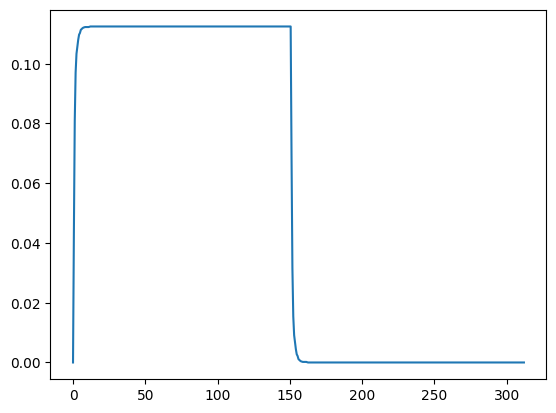

In [683]:
rec = pd.read_csv('/Users/paulbaity/Geant4/BNL_G4CMP/Main/Sensitivity/output_test_wall0.025.txt')
# rec = pd.read_csv('/Users/paulbaity/Geant4/BNL_G4CMP/Main/macros/phonon_hits_Cu1umInj_0p025WallAbs_Q0Inj_1B_10x10_45Deg_TrueJJ_newFilmAbs_200umIslands.txt')
times, QPs = calculate_QPs(rec,191.0e-6)
dt = np.mean(np.diff(times))*0.001 #time resolution
t = np.linspace(0.001*times[0], 0.001*times[-1] + 300, len(times) + int(np.round(300/dt)))
g_QP = np.zeros((QPs.shape[0],len(t)))
n_QP = np.zeros((QPs.shape[0],len(t)))
N_sim = 1000000000

for k in range(QPs.shape[0]):
    n_QP[k,:len(QPs[k])] += QPs[k,:]
    for i in range(len(g_QP[k])):
        s = 0
        for j in range(0,i):
            if t[j] <= pt:
                I = I_ph
            else:
                I = 0
            s += n_QP[k,i-j]*I
        g_QP[k,i] = s/(0.6*20*N_sim)

plt.plot(t,g_QP[5])
tl = t

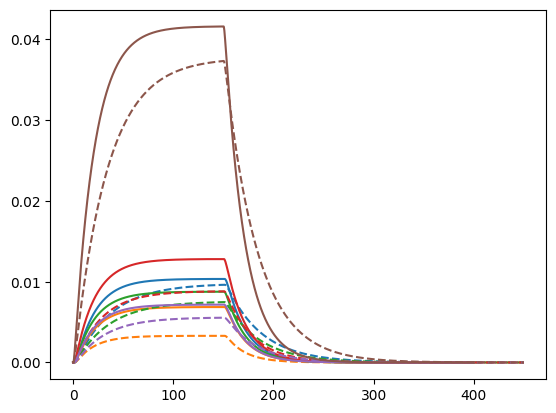

In [97]:
time_sol = np.array([])
n_qp_sol = np.array([])
for q in range(0,6):
    t = np.loadtxt("/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/Cu_1um_Injection_time_sol_"+str(q))
    n = np.loadtxt("/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/Cu_1um_Injection_n_qp_sol_"+str(q))
    time_sol = np.append(time_sol,t)
    n_qp_sol = np.append(n_qp_sol,n)
    plt.plot(t,Factor[q]*n/4e6,'C'+str(q)+'-')
    plt.plot(nt[:],Factor[q]*DG[q,:],'C'+str(q)+'--')

Text(0.5, 0, 'Time (us)')

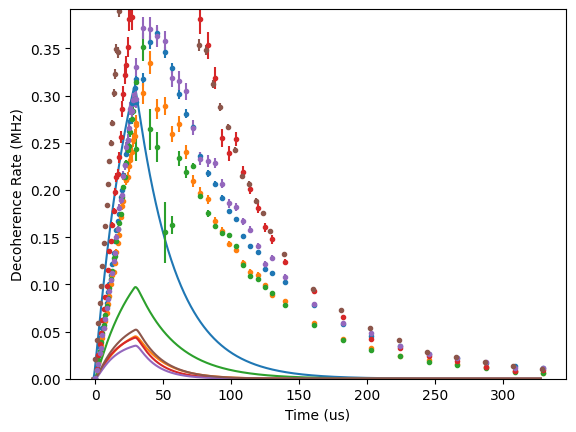

In [399]:
def calculate_QPs(rec,gap):
    ssn = 1001 # Number of time datapoints
    qx = np.array([-1.64,-2.4405,0.4,-0.4,2.42,1.62]) # Qubit x-locations
    qy = np.array([2.2795,-2.2735,2.2735,-2.2795,2.2795,-2.2735]) #Qubit y-locations
    phNos = np.zeros((len(qx),ssn)) # Number of phonons which hit each qubit at a given time division
    QPNos = np.zeros((len(qx),ssn)) # Number of quasiparticles generated on each qubit at a given time division
    snapshot_t = np.linspace(0, 300000, ssn) # Time vector in ns
    hits = np.where((rec['Energy Deposited [eV]'] > 0) & (rec['End Z [m]'] == 0.0002625))[0]

    #For each hit, determine which qubit the phonon struck and at what time division; build the statistics for phNos and QPNos
    #2*179.75e-6 is the energy required to make 1 quasiparticle. Energy Deposited will always be an integer multiple of this value.
    for h in hits:
        r = ((1000*rec['End X [m]'][h] - qx)**2 + (1000*rec['End Y [m]'][h] - qy)**2)**0.5
        q = np.argmin(r)
        # for q in range(len(qx)):
        #     if np.round(1000*rec['End X [m]'][h],2) == np.round(qx[q],2) and np.round(1000*rec['End Y [m]'][h],2) == np.round(qy[q],2):
                # print("truth condition met")
        phNos[q,np.argmin(np.abs(rec['Final Time [ns]'][h] - snapshot_t))] += 1
        QPNos[q,np.argmin(np.abs(rec['Final Time [ns]'][h] - snapshot_t))] += int(np.round(rec['Energy Deposited [eV]'][h]/(2*gap)))

    return snapshot_t, QPNos
    
def calculate_xQPs(snapshot_t,QPNos,AlGap,f_01,r,s,I_ph,pt,n_cooper,height,width,thickness):
    # pt = 10 #pulse time in us
    dt = np.mean(np.diff(snapshot_t))*0.001 #time resolution
    t = np.linspace(0.001*snapshot_t[0], 0.001*snapshot_t[-1] + pt, len(snapshot_t) + int(np.round(pt/dt)))
    g_QP = np.zeros((QPNos.shape[0],len(t)))
    x_QP = np.zeros((QPNos.shape[0],len(t)))
    Factor = 2*np.sqrt(2*AlGap*f_01[:])*1e-6
    DG = np.zeros((QPNos.shape[0],len(t)))

    for k in range(QPNos.shape[0]):
        for i in range(int(np.round(pt/dt))):
            g_QP[k,i:len(QPNos[k,:])+i] += QPNos[k,:]*I_ph/(n_cooper*height*width*thickness*100000000)
    
        for i in range(len(g_QP[k,:])-1):
            dx = (-r*x_QP[k,i]**2 - s[k]*x_QP[k,i] + g_QP[k,i])*dt
            x_QP[k,i+1] = x_QP[k,i] + dx

        DG[k,:] = x_QP[k,:]*Factor[k]
    
    # return snapshot_t, QPNos
    return t, DG
    
# rec = pd.read_csv('/Users/paulbaity/Geant4/BNL_G4CMP/Main/Sensitivity/output_test_wall0.025.txt')
rec = pd.read_csv('/Users/paulbaity/Geant4/BNL_G4CMP/Main/macros/phonon_hits_Cu1umInj_0p025WallAbs_Q0Inj_1B_10x10_45Deg_TrueJJ_newFilmAbs_200umIslands.txt')
times, QPs = calculate_QPs(rec,191.0e-6)

height = 10
width = 10
thickness = 0.12
n_cooper = 4.0e6
pt = 30
I_ph = 1.67259*8.916441535e5
# s = np.array([0.02808,0.0523,0.0292,0.0371,0.0331,0.03038])
s = np.array([0.0543,0.0693,0.0634,0.0342,0.0512,0.0342])
r = 25e-6
# f_01 = np.array([4.62e9,4.30e9,4.32e9,4.36e9,4.34e9,4.32e9])
f_01 = np.array([4.60e9,4.58e9,4.11e9,4.32e9,4.10e9,4.18e9])
AlGap = 191.0e-6/(4.135667696e-15)
nt, DG = calculate_xQPs(times,QPs,AlGap,f_01,r,s,I_ph,pt,n_cooper,height,width,thickness)

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_Q0Inj_30us_vAvg/Qubit_5_NbGND_EY02_B5_DeltaGamma_v_Delay_Q0inj_30us_DuringPulse.txt',delimiter =' ',skiprows=0)
x = delay_data[0]
y = delay_data[1]
dy = delay_data[2]

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_Q0Inj_30us_vAvg/Qubit_5_NbGND_EY02_B5_DeltaGamma_v_Delay_Q0inj_30us.txt',delimiter =' ',skiprows=0)
x0_data = np.append(x,delay_data[0]) - np.min(x)
y0_data = np.append(y,delay_data[1])
dy0_data = np.append(dy,delay_data[2])
plt.figure()
plt.errorbar(x0_data,y0_data,yerr=dy0_data, fmt = '.', color = 'C0', label = 'Experimental Data')

plt.plot(nt-2,DG[5,:], color = 'C0')
# plt.fill_between(nt-2,DG[5,:], alpha = 0.3, color = 'C0')
plt.ylim(0,)
plt.ylabel('Decoherence Rate (MHz)')
plt.xlabel('Time (us)')

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_Q0Inj_30us_vAvg/Qubit_4_NbGND_EY02_B5_DeltaGamma_v_Delay_Q0inj_30us_DuringPulse.txt',delimiter =' ',skiprows=0)
x = delay_data[0]
y = delay_data[1]
dy = delay_data[2]

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_Q0Inj_30us_vAvg/Qubit_4_NbGND_EY02_B5_DeltaGamma_v_Delay_Q0inj_30us.txt',delimiter =' ',skiprows=0)
x1_data = np.append(x,delay_data[0]) - np.min(x)
y1_data = np.append(y,delay_data[1])
dy1_data = np.append(dy,delay_data[2])
# plt.figure()
plt.errorbar(x1_data,y1_data,yerr=dy1_data, fmt = '.', color = 'C1', label = 'Experimental Data')

plt.plot(nt-2,DG[4,:],color = 'C1')
# plt.fill_between(nt-2,DG[4,:], alpha = 0.3, color = 'C1')
plt.ylim(0,)
plt.ylabel('Decoherence Rate (MHz)')
plt.xlabel('Time (us)')

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_Q0Inj_30us_vAvg/Qubit_3_NbGND_EY02_B5_DeltaGamma_v_Delay_Q0inj_30us_DuringPulse.txt',delimiter =' ',skiprows=0)
x = delay_data[0]
y = delay_data[1]
dy = delay_data[2]

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_Q0Inj_30us_vAvg/Qubit_3_NbGND_EY02_B5_DeltaGamma_v_Delay_Q0inj_30us.txt',delimiter =' ',skiprows=0)
x2_data = np.append(x,delay_data[0]) - np.min(x)
y2_data = np.append(y,delay_data[1])
dy2_data = np.append(dy,delay_data[2])
# plt.figure()
plt.errorbar(x2_data,y2_data,yerr=dy2_data, fmt = '.', color = 'C2', label = 'Experimental Data')

plt.plot(nt-2,DG[3,:],color = 'C2')
# plt.fill_between(nt-2,DG[3,:], alpha = 0.3, color = 'C2')
plt.ylim(0,)
plt.ylabel('Decoherence Rate (MHz)')
plt.xlabel('Time (us)')

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_Q0Inj_30us_vAvg/Qubit_2_NbGND_EY02_B5_DeltaGamma_v_Delay_Q0inj_30us_DuringPulse.txt',delimiter =' ',skiprows=0)
x = delay_data[0]
y = delay_data[1]
dy = delay_data[2]

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_Q0Inj_30us_vAvg/Qubit_2_NbGND_EY02_B5_DeltaGamma_v_Delay_Q0inj_30us.txt',delimiter =' ',skiprows=0)
x3_data = np.append(x,delay_data[0]) - np.min(x)
y3_data = np.append(y,delay_data[1])
dy3_data = np.append(dy,delay_data[2])
# plt.figure()
plt.errorbar(x3_data,y3_data,yerr=dy3_data, fmt = '.', color = 'C3', label = 'Experimental Data')

plt.plot(nt-2,DG[2,:],color = 'C3')
# plt.fill_between(nt-2,DG[2,:], alpha = 0.3, color = 'C3')
plt.ylim(0,)
plt.ylabel('Decoherence Rate (MHz)')
plt.xlabel('Time (us)')

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_Q0Inj_30us_vAvg/Qubit_1_NbGND_EY02_B5_DeltaGamma_v_Delay_Q0inj_30us_DuringPulse.txt',delimiter =' ',skiprows=0)
x = delay_data[0]
y = delay_data[1]
dy = delay_data[2]

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_Q0Inj_30us_vAvg/Qubit_1_NbGND_EY02_B5_DeltaGamma_v_Delay_Q0inj_30us.txt',delimiter =' ',skiprows=0)
x4_data = np.append(x,delay_data[0]) - np.min(x)
y4_data = np.append(y,delay_data[1])
dy4_data = np.append(dy,delay_data[2])
# plt.figure()
plt.errorbar(x4_data,y4_data,yerr=dy4_data, fmt = '.', color = 'C4', label = 'Experimental Data')

plt.plot(nt-2,DG[1,:],color = 'C4')
# plt.fill_between(nt-2,DG[1,:], alpha = 0.3, color = 'C4')
plt.ylim(0,)
plt.ylabel('Decoherence Rate (MHz)')
plt.xlabel('Time (us)')

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_Q0Inj_30us_vAvg/Qubit_0_NbGND_EY02_B5_DeltaGamma_v_Delay_Q0inj_30us_DuringPulse.txt',delimiter =' ',skiprows=0)
x = delay_data[0]
y = delay_data[1]
dy = delay_data[2]

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_Q0Inj_30us_vAvg/Qubit_0_NbGND_EY02_B5_DeltaGamma_v_Delay_Q0inj_30us.txt',delimiter =' ',skiprows=0)
x5_data = np.append(x,delay_data[0]) - np.min(x)
y5_data = np.append(y,delay_data[1])
dy5_data = np.append(dy,delay_data[2])
# plt.figure()
plt.errorbar(x5_data,y5_data,yerr=dy5_data, fmt = '.', color = 'C5', label = 'Experimental Data')

plt.plot(nt-2,DG[0,:],color = 'C5')
# plt.fill_between(nt-2,DG[0,:], alpha = 0.3, color = 'C5')
plt.ylim(0,)
plt.ylabel('Decoherence Rate (MHz)')
plt.xlabel('Time (us)')

24334


(-4.0, 4.0)

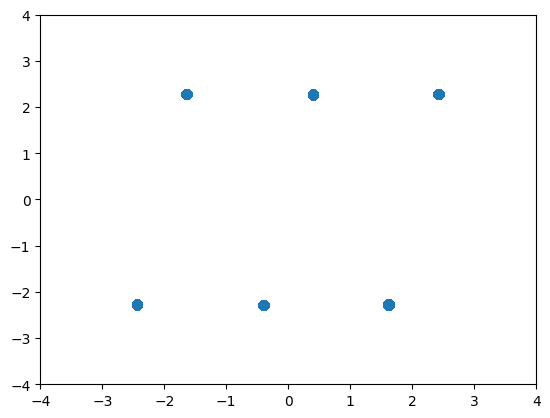

In [379]:
rec = pd.read_csv('/Users/paulbaity/Geant4/BNL_G4CMP/Main/Sensitivity/output_test_wall0.025.txt')
hits = np.where((rec['Energy Deposited [eV]'] > 0) & (rec['End Z [m]'] == 0.0002625))[0]
print(len(hits))
plt.scatter(1000*rec['End X [m]'][hits],1000*rec['End Y [m]'][hits])
plt.ylim(-4,4)
plt.xlim(-4,4)

<Figure size 8400x8400 with 0 Axes>

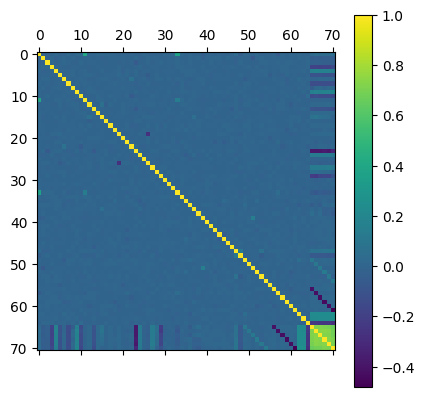

In [5]:

# sequence = pd.read_csv('/Users/paulbaity/Geant4/BNL_G4CMP/Main/Sensitivity/1673d18b-129c-4957-bc60-b585bee03145_hits/SobolSequence.csv')
trials = []
for i in range(0,len(output_x)):
    if len(output_x[i])>0 and np.sum(output_y0[i])>0 and np.sum(output_y1[i])>0 and np.sum(output_y2[i])>0 and np.sum(output_y3[i])>0 and np.sum(output_y4[i])>0 and np.sum(output_y5[i])>0:
        t = sequence.values[i,:]
        t = np.append(t,np.log10(np.sum(output_y0[i]*np.mean(np.diff(output_x[i])))))
        t = np.append(t,np.log10(np.sum(output_y1[i]*np.mean(np.diff(output_x[i])))))
        t = np.append(t,np.log10(np.sum(output_y2[i]*np.mean(np.diff(output_x[i])))))
        t = np.append(t,np.log10(np.sum(output_y3[i]*np.mean(np.diff(output_x[i])))))
        t = np.append(t,np.log10(np.sum(output_y4[i]*np.mean(np.diff(output_x[i])))))
        t = np.append(t,np.log10(np.sum(output_y5[i]*np.mean(np.diff(output_x[i])))))
        trials.append(t)

plt.figure(figsize = (7,7),dpi = 1200)
A = np.corrcoef(trials, rowvar=False)
plt.matshow(A)
plt.colorbar()

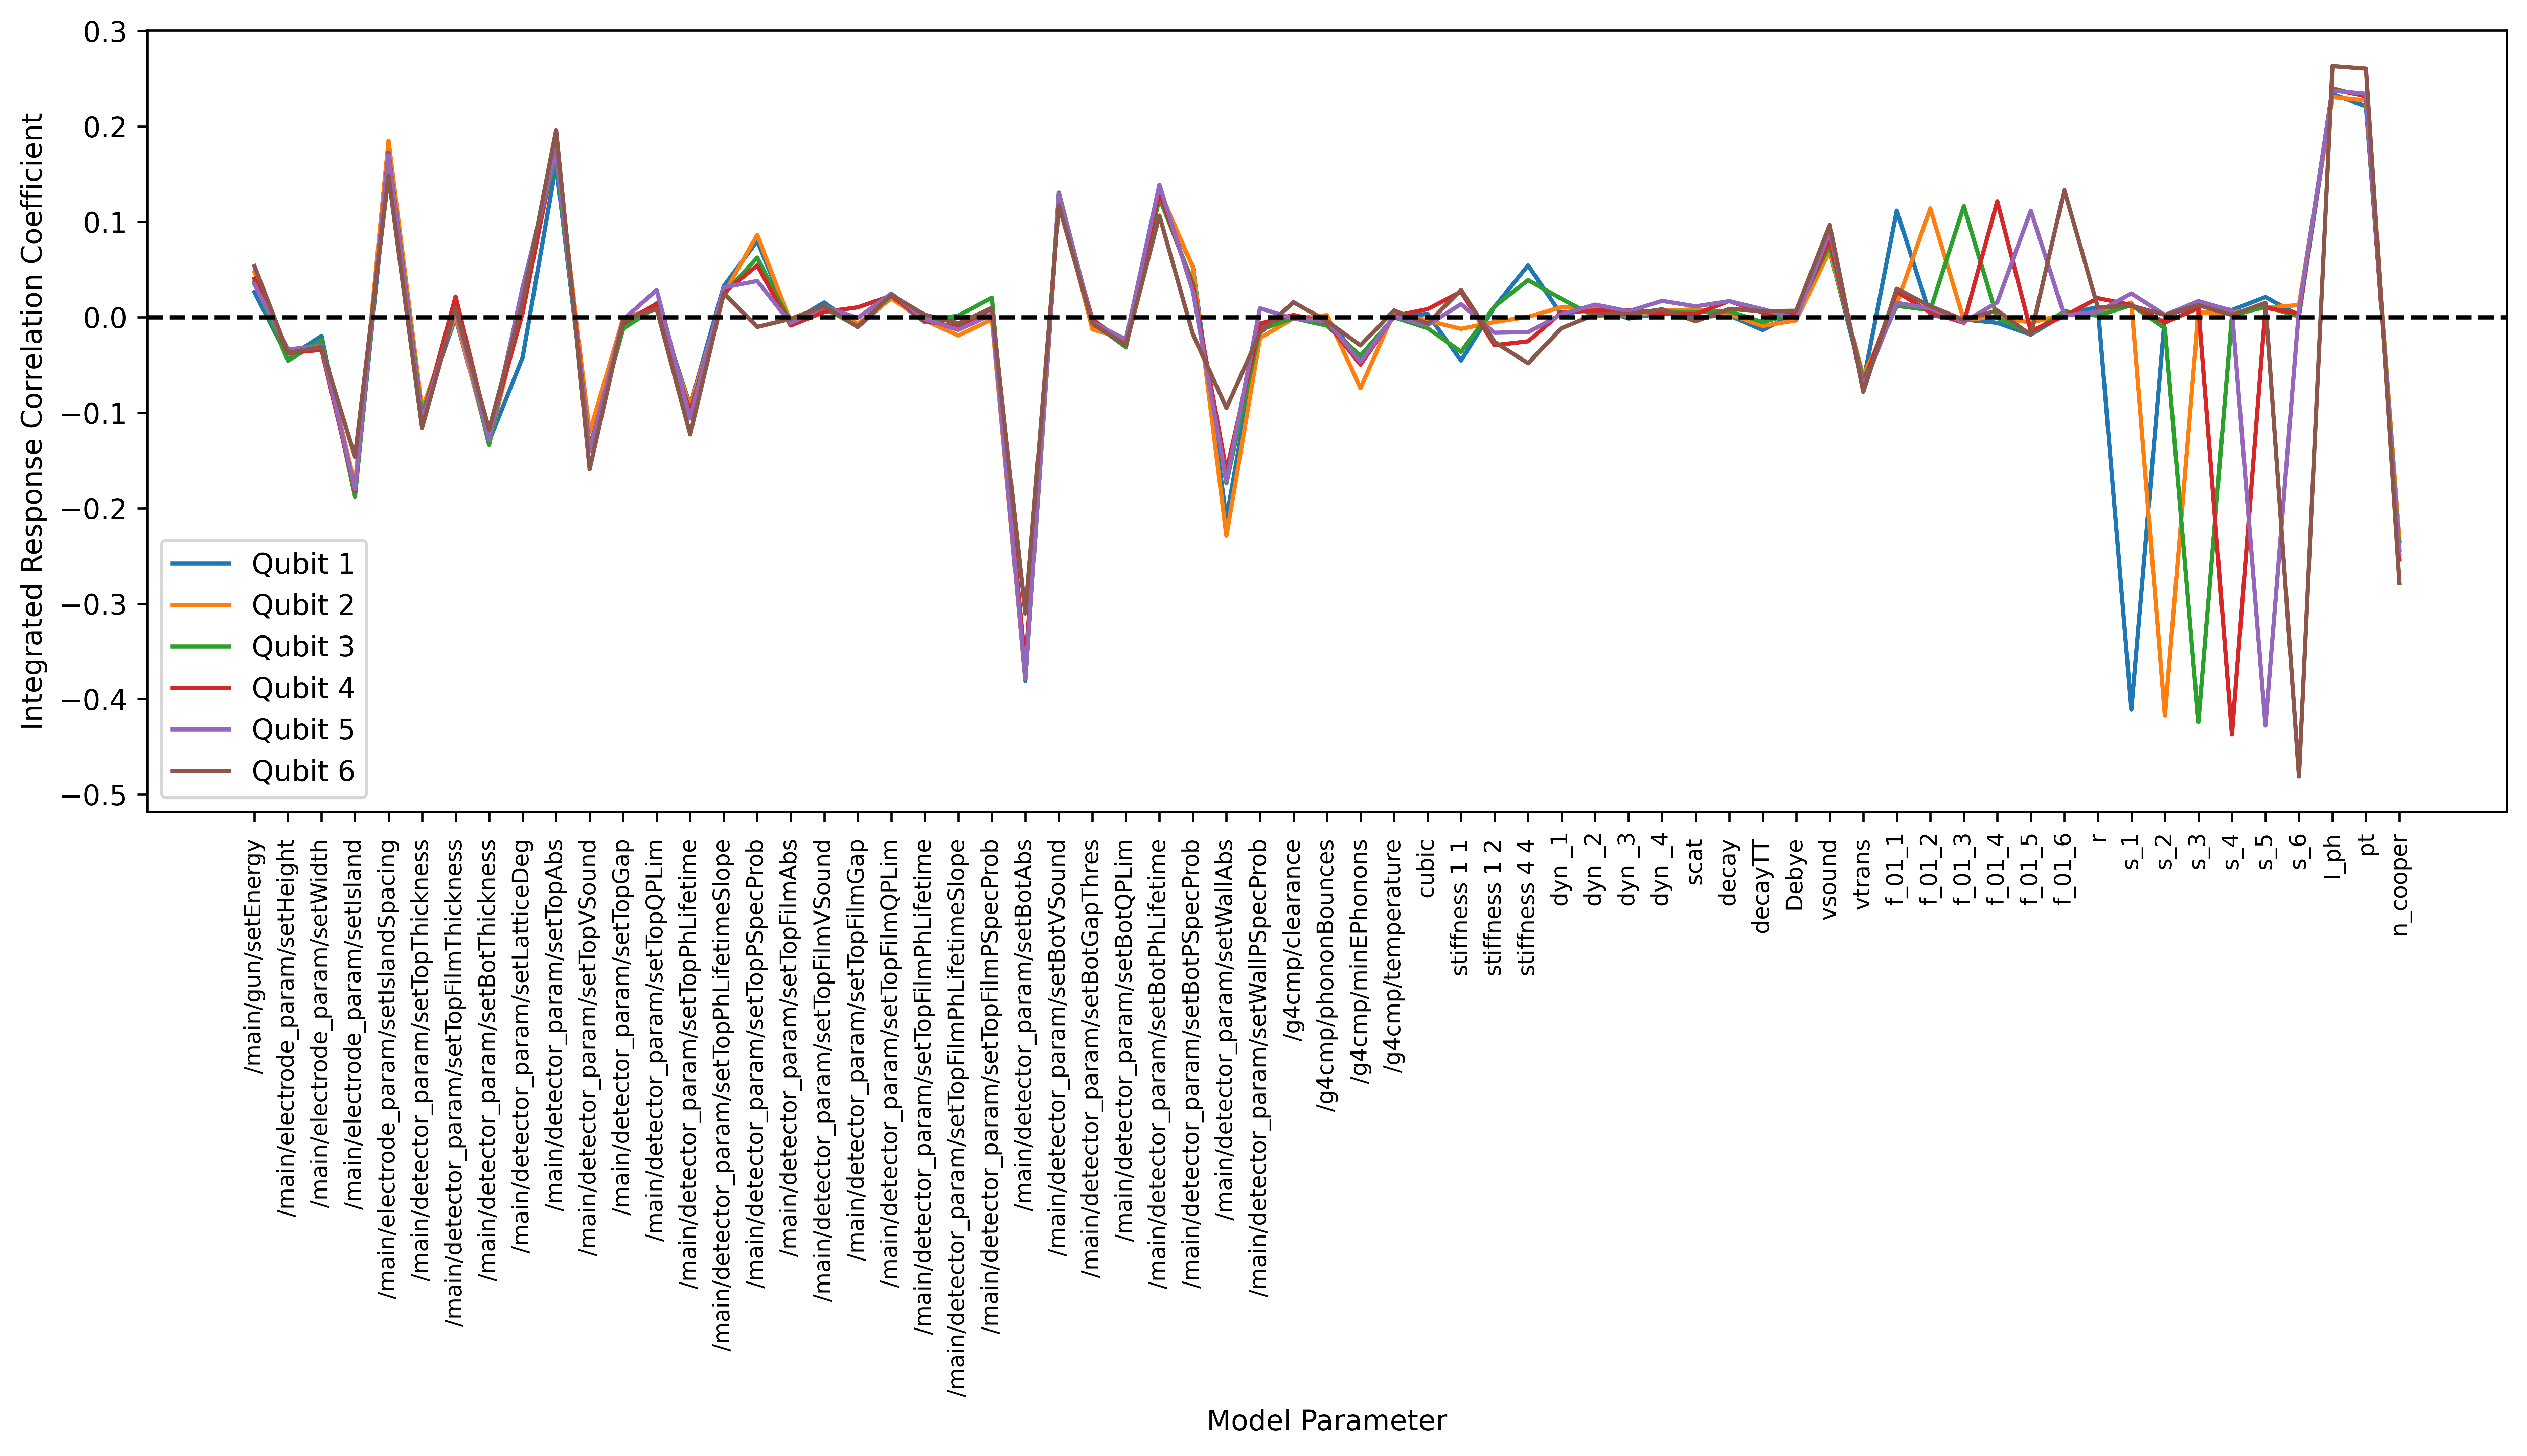

In [7]:
fig, ax = plt.subplots(figsize = (15,5), dpi = 600)
plt.plot(A[-6][:-6], label = 'Qubit 1')
plt.plot(A[-5][:-6], label = 'Qubit 2')
plt.plot(A[-4][:-6], label = 'Qubit 3')
plt.plot(A[-3][:-6], label = 'Qubit 4')
plt.plot(A[-2][:-6], label = 'Qubit 5')
plt.plot(A[-1][:-6], label = 'Qubit 6')
plt.xticks(range(len(A[-6][:-6])),rotation=90, fontsize = 8)
ax.set_xticklabels(sequence.columns.values.tolist())
plt.ylabel("Integrated Response Correlation Coefficient")
plt.xlabel("Model Parameter")
plt.legend(loc = 'lower left')
plt.axhline(0,linestyle = '--', color = 'k')

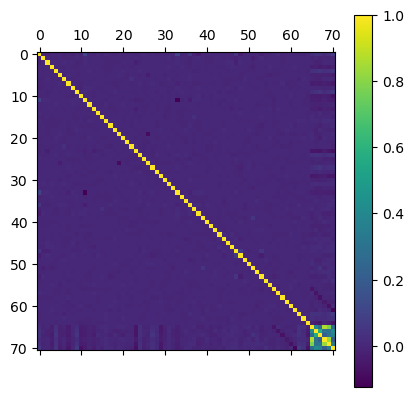

In [3]:

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_1umCu_B2_Q0Inj_150us_staggered/Qubit_5_NbGND_1umCu_VI09_B2_DeltaGamma_v_Delay_Q0inj_150us_DuringPulse.txt',delimiter =' ',skiprows=0)
x = delay_data[0]
y = delay_data[1]
dy = delay_data[2]

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_1umCu_B2_Q0Inj_150us_staggered/Qubit_5_NbGND_1umCu_VI09_B2_DeltaGamma_v_Delay_Q0inj_150us.txt',delimiter =' ',skiprows=0)
x0_data = np.append(x,delay_data[0]) - np.min(x)
y0_data = np.append(y,delay_data[1])
dy0_data = np.append(dy,delay_data[2])
# plt.errorbar(x0_data,y0_data,yerr=dy0_data, fmt = '.', color = 'k', label = 'Experimental Data')

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_1umCu_B2_Q0Inj_150us_staggered/Qubit_4_NbGND_1umCu_VI09_B2_DeltaGamma_v_Delay_Q0inj_150us_DuringPulse.txt',delimiter =' ',skiprows=0)
x = delay_data[0]
y = delay_data[1]
dy = delay_data[2]

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_1umCu_B2_Q0Inj_150us_staggered/Qubit_4_NbGND_1umCu_VI09_B2_DeltaGamma_v_Delay_Q0inj_150us.txt',delimiter =' ',skiprows=0)
x1_data = np.append(x,delay_data[0]) - np.min(x)
y1_data = np.append(y,delay_data[1])
dy1_data = np.append(dy,delay_data[2])
# plt.errorbar(x1_data,y1_data,yerr=dy1_data, fmt = '.', color = 'k', label = 'Experimental Data')

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_1umCu_B2_Q0Inj_150us_staggered/Qubit_3_NbGND_1umCu_VI09_B2_DeltaGamma_v_Delay_Q0inj_150us_DuringPulse.txt',delimiter =' ',skiprows=0)
x = delay_data[0]
y = delay_data[1]
dy = delay_data[2]

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_1umCu_B2_Q0Inj_150us_staggered/Qubit_3_NbGND_1umCu_VI09_B2_DeltaGamma_v_Delay_Q0inj_150us.txt',delimiter =' ',skiprows=0)
x2_data = np.append(x,delay_data[0]) - np.min(x)
y2_data = np.append(y,delay_data[1])
dy2_data = np.append(dy,delay_data[2])
# plt.errorbar(x2_data,y2_data,yerr=dy2_data, fmt = '.', color = 'k', label = 'Experimental Data')

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_1umCu_B2_Q0Inj_150us_staggered/Qubit_2_NbGND_1umCu_VI09_B2_DeltaGamma_v_Delay_Q0inj_150us_DuringPulse.txt',delimiter =' ',skiprows=0)
x = delay_data[0]
y = delay_data[1]
dy = delay_data[2]

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_1umCu_B2_Q0Inj_150us_staggered/Qubit_2_NbGND_1umCu_VI09_B2_DeltaGamma_v_Delay_Q0inj_150us.txt',delimiter =' ',skiprows=0)
x3_data = np.append(x,delay_data[0]) - np.min(x)
y3_data = np.append(y,delay_data[1])
dy3_data = np.append(dy,delay_data[2])
# plt.errorbar(x3_data,y3_data,yerr=dy3_data, fmt = '.', color = 'k', label = 'Experimental Data')

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_1umCu_B2_Q0Inj_150us_staggered/Qubit_1_NbGND_1umCu_VI09_B2_DeltaGamma_v_Delay_Q0inj_150us_DuringPulse.txt',delimiter =' ',skiprows=0)
x = delay_data[0]
y = delay_data[1]
dy = delay_data[2]

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_1umCu_B2_Q0Inj_150us_staggered/Qubit_1_NbGND_1umCu_VI09_B2_DeltaGamma_v_Delay_Q0inj_150us.txt',delimiter =' ',skiprows=0)
x4_data = np.append(x,delay_data[0]) - np.min(x)
y4_data = np.append(y,delay_data[1])
dy4_data = np.append(dy,delay_data[2])
# plt.errorbar(x4_data,y4_data,yerr=dy4_data, fmt = '.', color = 'k', label = 'Experimental Data')

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_1umCu_B2_Q0Inj_150us_staggered/Qubit_0_NbGND_1umCu_VI09_B2_DeltaGamma_v_Delay_Q0inj_150us_DuringPulse.txt',delimiter =' ',skiprows=0)
x = delay_data[0]
y = delay_data[1]
dy = delay_data[2]

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_1umCu_B2_Q0Inj_150us_staggered/Qubit_0_NbGND_1umCu_VI09_B2_DeltaGamma_v_Delay_Q0inj_150us.txt',delimiter =' ',skiprows=0)
x5_data = np.append(x,delay_data[0]) - np.min(x)
y5_data = np.append(y,delay_data[1])
dy5_data = np.append(dy,delay_data[2])
# plt.errorbar(x5_data,y5_data,yerr=dy5_data, fmt = '.', color = 'k', label = 'Experimental Data')

sequence = pd.read_csv('/Users/paulbaity/Geant4/BNL_G4CMP/Main/Sensitivity/1673d18b-129c-4957-bc60-b585bee03145_hits/SobolSequence.csv')
trials = []
for i in range(0,len(output_x)):
    if len(output_x[i])>0:
        t = sequence.values[i,:]
        
        chisquare = 0
        for j in range(len(x0_data)):
            point = np.argmin(np.abs(x0_data[j]-output_x[i]))
            chisquare += ((output_y0[i][point] - y0_data[j])**2)#/y0_data[j]
        t = np.append(t,chisquare)

        chisquare = 0
        for j in range(len(x1_data)):
            point = np.argmin(np.abs(x1_data[j]-output_x[i]))
            chisquare += ((output_y1[i][point] - y1_data[j])**2)#/y1_data[j]
        t = np.append(t,chisquare)

        chisquare = 0
        for j in range(len(x2_data)):
            point = np.argmin(np.abs(x2_data[j]-output_x[i]))
            chisquare += ((output_y2[i][point] - y2_data[j])**2)#/y2_data[j]
        t = np.append(t,chisquare)

        chisquare = 0
        for j in range(len(x3_data)):
            point = np.argmin(np.abs(x3_data[j]-output_x[i]))
            chisquare += ((output_y3[i][point] - y3_data[j])**2)#/y3_data[j]
        t = np.append(t,chisquare)

        chisquare = 0
        for j in range(len(x4_data)):
            point = np.argmin(np.abs(x4_data[j]-output_x[i]))
            chisquare += ((output_y4[i][point] - y4_data[j])**2)#/y4_data[j]
        t = np.append(t,chisquare)

        chisquare = 0
        for j in range(len(x5_data)):
            point = np.argmin(np.abs(x5_data[j]-output_x[i]))
            chisquare += ((output_y5[i][point] - y5_data[j])**2)#/y5_data[j]
        t = np.append(t,chisquare)
        
        trials.append(t)
        # plt.plot(output_x[i],output_y4[i])

# plt.ylabel('$\Delta\Gamma$ (MHz)')
# plt.xlabel('Time ($\mu$s)')
# plt.legend(loc = 'upper right')

# plt.figure(figsize = (7,7),dpi = 1200)
A = np.corrcoef(trials, rowvar=False)
plt.matshow(A)
plt.colorbar()

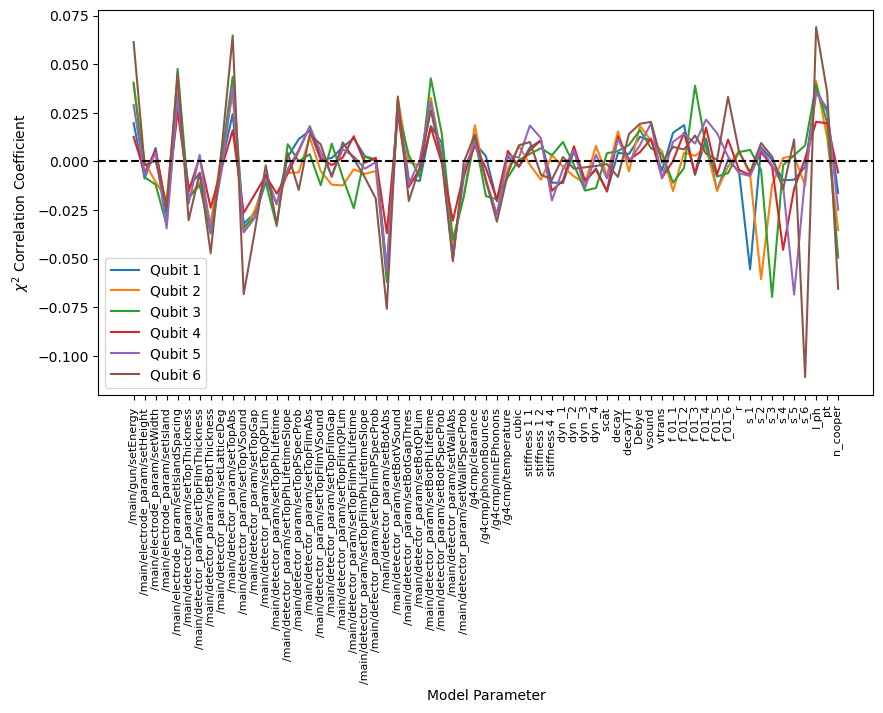

In [5]:
fig, ax = plt.subplots(figsize = (10,5))
plt.plot(A[-6][:-6], label = 'Qubit 1')
plt.plot(A[-5][:-6], label = 'Qubit 2')
plt.plot(A[-4][:-6], label = 'Qubit 3')
plt.plot(A[-3][:-6], label = 'Qubit 4')
plt.plot(A[-2][:-6], label = 'Qubit 5')
plt.plot(A[-1][:-6], label = 'Qubit 6')
plt.xticks(range(len(A[-1][:-6])),rotation=90, fontsize = 8)
ax.set_xticklabels(sequence.columns.values.tolist())
plt.ylabel(r"$\chi^2$ Correlation Coefficient")
plt.xlabel("Model Parameter")
plt.legend(loc = 'lower left')
plt.axhline(0,linestyle = '--', color = 'k')

9435


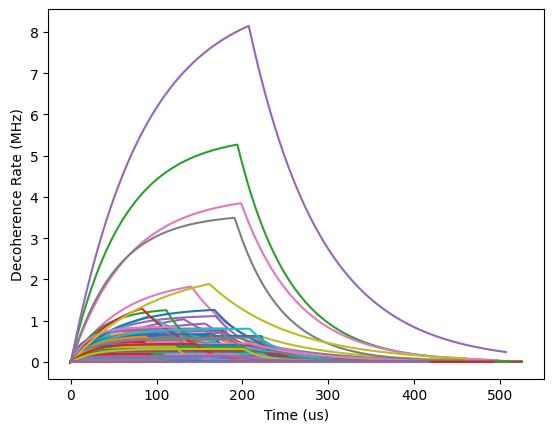

In [259]:
def calculate_QPs(rec,gap):
    ssn = 1001 # Number of time datapoints
    phNos = np.zeros(ssn) # Number of phonons which hit each qubit at a given time division
    QPNos = np.zeros(ssn) # Number of quasiparticles generated on each qubit at a given time division
    snapshot_t = np.linspace(0, 300000, ssn) # Time vector in ns
    hits = np.where((rec['Energy Deposited [eV]'] > 0) & (rec['End Z [m]'] == 0.0002625))[0]

    #For each hit, determine which qubit the phonon struck and at what time division; build the statistics for phNos and QPNos
    #2*179.75e-6 is the energy required to make 1 quasiparticle. Energy Deposited will always be an integer multiple of this value.
    for h in hits:
        phNos[np.argmin(np.abs(rec['Final Time [ns]'][h] - snapshot_t))] += 1
        QPNos[np.argmin(np.abs(rec['Final Time [ns]'][h] - snapshot_t))] += int(np.round(rec['Energy Deposited [eV]'][h]/(2*gap)))

    return snapshot_t, QPNos

def calculate_xQPs(snapshot_t,QPNos,AlGap,f_01,r,s,I_ph,pt,n_cooper,height,width,thickness):
    # pt = 10 #pulse time in us
    dt = np.mean(np.diff(snapshot_t))*0.001 #time resolution
    t = np.linspace(0.001*snapshot_t[0], 0.001*snapshot_t[-1] + pt, len(snapshot_t) + int(np.round(pt/dt)))
    g_QP = np.zeros(len(t))
    x_QP = np.zeros(len(t))
    Factor = 2*np.sqrt(2*AlGap*f_01)*1e-6
    DG = np.zeros(len(t))

    for i in range(int(np.round(pt/dt))):
        g_QP[i:len(QPNos[:])+i] = g_QP[i:len(QPNos[:])+i] + QPNos[:]*I_ph/(n_cooper*height*width*thickness*1e8)
    
    for i in range(len(g_QP[:])-1):
        dx = (-r*x_QP[i]**2 - s*x_QP[i] + g_QP[i])*dt
        x_QP[i+1] = x_QP[i] + dx

    DG[:] = x_QP[:]*Factor
    
    return t, DG

sequence = pd.read_csv('/Users/paulbaity/Geant4/BNL_G4CMP/Main/Sensitivity/hits/SobolSequence.csv')
output_x = []
output_y = []
good = 0
for i in range(1,2**14):
    try:
        rec = pd.read_csv('/Users/paulbaity/Geant4/BNL_G4CMP/Main/Sensitivity/hits/Sobol_' + str(i) + '_hitsfile.txt')
        if len(rec) > 0:
            AlGap = sequence["/main/detector_param/setTopGap "][i]
            times, QPs = calculate_QPs(rec,AlGap)
            height = sequence["/main/electrode_param/setHeight "][i]
            width = sequence["/main/electrode_param/setWidth "][i]
            thickness = sequence["/main/detector_param/setTopThickness "][i]
            n_cooper = sequence["n_cooper"][i]
            pt = 5*sequence["pt"][i]
            I_ph = sequence["I_ph"][i]
            s = sequence["s"][i]
            r = sequence["r"][i]
            f_01 = sequence["f_01"][i]
            # AlGap = sequence["AlGap"][i]
            AlGap = sequence["/main/detector_param/setTopGap "][i]/(4.135667696e-15)
            # print(AlGap,AlGap1)
            nt, DG = calculate_xQPs(times,QPs,AlGap,f_01,r,s,I_ph,pt,n_cooper,height,width,thickness)

            plt.plot(nt,DG[:])
            output_x.append(nt)
            output_y.append(DG)
            good += 1

        else:
            output_x.append([])
            output_y.append([])

    except:
        output_x.append([])
        output_y.append([])

plt.ylabel('Decoherence Rate (MHz)')
plt.xlabel('Time (us)')
# plt.yscale('log')
print(good)

<Figure size 8400x8400 with 0 Axes>

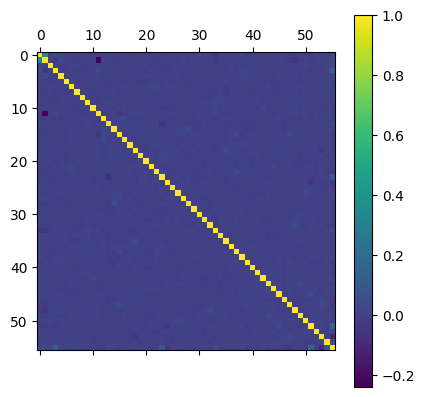

In [271]:
sequence = pd.read_csv('/Users/paulbaity/Geant4/BNL_G4CMP/Main/Sensitivity/hits/SobolSequence.csv')
trials = []
s = []
for i in range(0,len(output_x)):
    if len(output_y[i])>0 and np.sum(output_y[i])>0:
        t = sequence.values[i,:]
        t = np.append(t,np.log10(np.sum(output_y[i][:]*np.mean(np.diff(output_x[i][:])))))
        s.append(np.sum(output_y[i][:]*np.mean(np.diff(output_x[i][:]))))
        trials.append(t)

plt.figure(figsize = (7,7),dpi = 1200)
A = np.corrcoef(trials, rowvar=False)
plt.matshow(A)
plt.colorbar()

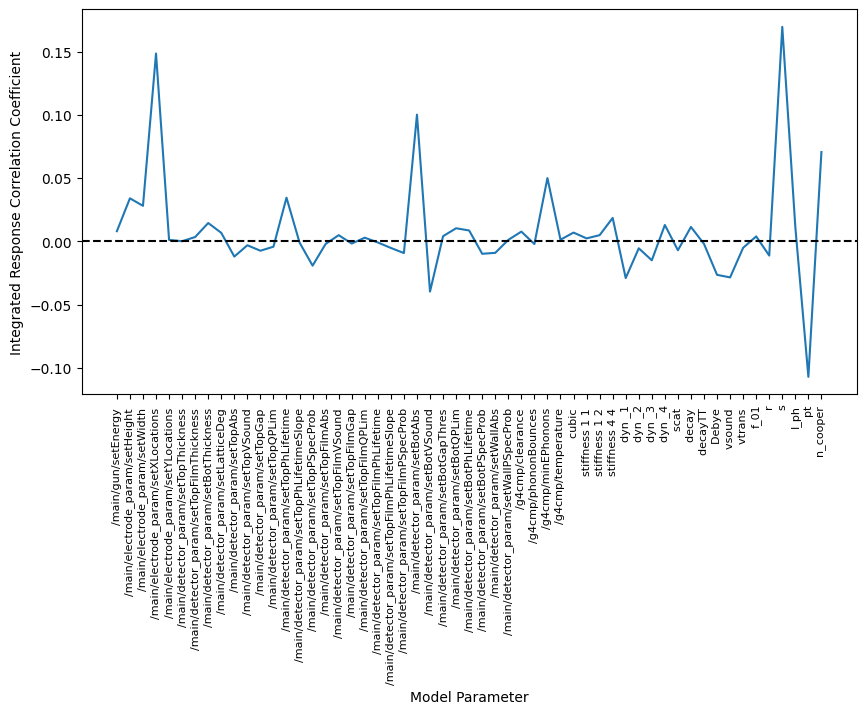

In [273]:
fig, ax = plt.subplots(figsize = (10,5))
plt.plot(A[-1][:-1])
plt.xticks(range(len(A[-1][:-1])),rotation=90, fontsize = 8)
ax.set_xticklabels(sequence.columns.values.tolist())
plt.ylabel("Integrated Response Correlation Coefficient")
plt.xlabel("Model Parameter")
# plt.legend(loc = 'lower left')
plt.axhline(0,linestyle = '--', color = 'k')

100


NameError: name 'Factor' is not defined

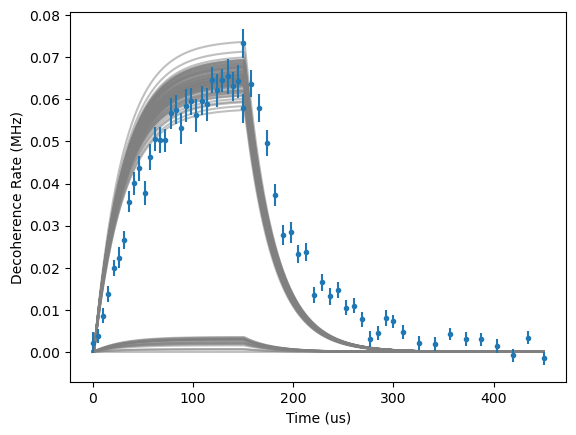

In [4]:
def calculate_QPs(rec,gap):
    ssn = 1001 # Number of time datapoints
    qx = np.array([-1.64,-2.4405,0.4,-0.4,2.42,1.62]) # Qubit x-locations
    qy = np.array([2.2795,-2.2735,2.2735,-2.2795,2.2795,-2.2735]) #Qubit y-locations
    phNos = np.zeros((len(qx),ssn)) # Number of phonons which hit each qubit at a given time division
    QPNos = np.zeros((len(qx),ssn)) # Number of quasiparticles generated on each qubit at a given time division
    snapshot_t = np.linspace(0, 300000, ssn) # Time vector in ns
    hits = np.where((rec['Energy Deposited [eV]'] > 0) & (rec['End Z [m]'] == 0.0002625))[0]

    #For each hit, determine which qubit the phonon struck and at what time division; build the statistics for phNos and QPNos
    #2*179.75e-6 is the energy required to make 1 quasiparticle. Energy Deposited will always be an integer multiple of this value.
    for h in hits:
        r = ((1000*rec['End X [m]'][h] - qx)**2 + (1000*rec['End Y [m]'][h] - qy)**2)**0.5
        q = np.argmin(r)
        # for q in range(len(qx)):
        #     if np.round(1000*rec['End X [m]'][h],2) == np.round(qx[q],2) and np.round(1000*rec['End Y [m]'][h],2) == np.round(qy[q],2):
                # print("truth condition met")
        phNos[q,np.argmin(np.abs(rec['Final Time [ns]'][h] - snapshot_t))] += 1
        QPNos[q,np.argmin(np.abs(rec['Final Time [ns]'][h] - snapshot_t))] += int(np.round(rec['Energy Deposited [eV]'][h]/(gap)))

    return snapshot_t, QPNos
    
def calculate_xQPs(snapshot_t,QPNos,AlGap,f_01,r,s,I_ph,pt,n_cooper,height,width,thickness):
    # pt = 10 #pulse time in us
    dt = np.mean(np.diff(snapshot_t))*0.001 #time resolution
    t = np.linspace(0.001*snapshot_t[0], 0.001*snapshot_t[-1] + pt, len(snapshot_t) + int(np.round(pt/dt)))
    g_QP = np.zeros((QPNos.shape[0],len(t)))
    x_QP = np.zeros((QPNos.shape[0],len(t)))
    Factor = 2*np.sqrt(2*AlGap*f_01[:])*1e-6
    DG = np.zeros((QPNos.shape[0],len(t)))
    N_sim = 1000000000*2.5/2

    signal = np.zeros(len(t))
    for i in range(len(t)):
        if t[i] <= pt:
            signal[i]=I_ph

    for k in range(QPNos.shape[0]):
        # for i in range(int(np.round(pt/dt))):
        #     g_QP[k,i:len(QPNos[k,:])+i] += QPNos[k,:]*I_ph/(n_cooper*height*width*thickness*N_sim)
            # g_QP[k,i:len(QPNos[k,:])+i] += QPNos[k,:]*I_ph/(0.6*20*N_sim*n_cooper)
        #     # g_QP[k,i] += np.sum(QPNos[k,:i])*I_ph/(0.6*20*N_sim)

        # Optional numpy.convolution method
        g_QP[k,:] = np.convolve(QPNos[k,:],signal,mode='full')[:len(t)]/(n_cooper*height*width*thickness*N_sim)
        
        for i in range(len(g_QP[k,:])-1):
            dx = (-r*x_QP[k,i]**2 - s[k]*x_QP[k,i] + g_QP[k,i])*dt
            x_QP[k,i+1] = x_QP[k,i] + dx

        DG[k,:] = x_QP[k,:]*Factor[k]
    
    # return snapshot_t, QPNos
    return t, DG

sequence = pd.read_csv('/Users/paulbaity/tara_files/Sensitivity/e91b895f-f800-4e20-8dab-b3cc977ad8b5_hits/1perc_Normal.csv')
output_x = []
output_y0 = []
output_y1 = []
output_y2 = []
output_y3 = []
output_y4 = []
output_y5 = []
good = 0
for i in range(0,100):
    try:
    # if 1 == 1:
        rec = pd.read_csv('/Users/paulbaity/tara_files/Sensitivity/e91b895f-f800-4e20-8dab-b3cc977ad8b5_hits/1perc_Normal_' + str(i) + '_hitsfile.txt')
        if len(rec) > 0:
            gap = sequence["/main/detector_param/setTopGap "][i]
            times, QPs = calculate_QPs(rec,gap)
            height = sequence["/main/electrode_param/setHeight "][i]
            width = sequence["/main/electrode_param/setWidth "][i]
            thickness = sequence["/main/detector_param/setTopThickness "][i]
            n_cooper = sequence["n_cooper"][i]
            pt = sequence["pt"][i]
            I_ph = sequence["I_ph"][i]
            s = np.array([sequence["s_1"][i],sequence["s_2"][i],sequence["s_3"][i],sequence["s_4"][i],sequence["s_5"][i],sequence["s_6"][i]])
            r = sequence["r"][i]
            f_01 = np.array([sequence["f_01_1"][i],sequence["f_01_2"][i],sequence["f_01_3"][i],sequence["f_01_4"][i],sequence["f_01_5"][i],sequence["f_01_6"][i]])
            # AlGap = sequence["AlGap"][i]
            AlGap = sequence["/main/detector_param/setTopGap "][i]/(4.135667696e-15)
            nt, DG = calculate_xQPs(times,QPs,AlGap,f_01,r,s,I_ph,150,n_cooper,height,width,thickness)

            plt.plot(nt,DG[5,:], color = 'gray', alpha = 0.5)
            output_x.append(nt)
            output_y0.append(DG[0,:])
            output_y1.append(DG[1,:])
            output_y2.append(DG[2,:])
            output_y3.append(DG[3,:])
            output_y4.append(DG[4,:])
            output_y5.append(DG[5,:])
            good += 1

        else:
            output_x.append([])
            output_y0.append([])
            output_y1.append([])
            output_y2.append([])
            output_y3.append([])
            output_y4.append([])
            output_y5.append([])

    except:
        output_x.append([])
        output_y0.append([])
        output_y1.append([])
        output_y2.append([])
        output_y3.append([])
        output_y4.append([])
        output_y5.append([])

plt.ylabel('Decoherence Rate (MHz)')
plt.xlabel('Time (us)')
print(good)

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_1umCu_B2_Q0Inj_150us_staggered/Qubit_0_NbGND_1umCu_VI09_B2_DeltaGamma_v_Delay_Q0inj_150us_DuringPulse.txt',delimiter =' ',skiprows=0)
x = delay_data[0]
y = delay_data[1]
dy = delay_data[2]

delay_data = np.loadtxt('/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/NbGND_1umCu_B2_Q0Inj_150us_staggered/Qubit_0_NbGND_1umCu_VI09_B2_DeltaGamma_v_Delay_Q0inj_150us.txt',delimiter =' ',skiprows=0)
x0_data = np.append(x,delay_data[0]) - np.min(x)
y0_data = np.append(y,delay_data[1])
dy0_data = np.append(dy,delay_data[2])
# plt.figure()
plt.errorbar(x0_data,y0_data,yerr=dy0_data, fmt = '.', color = 'C0', label = 'Qubit 6')

time_sol = np.array([])
n_qp_sol = np.array([])
for q in range(5,6):
    t = np.loadtxt("/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/Cu_1um_Injection_time_sol_"+str(q))
    n = np.loadtxt("/Users/paulbaity/Geant4/BNL_G4CMP/Scripts/python/Cu_1um_Injection_n_qp_sol_"+str(q))
    time_sol = np.append(time_sol,t)
    n_qp_sol = np.append(n_qp_sol,n)
    plt.plot(t,Factor[q]*n/4e6,'C'+str(5-q)+'-')
    plt.plot(nt[:],DG[q,:],'C'+str(5-q)+'--')